In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/Arrate/Desktop/Dataset/dataset_definitivo.csv")
df.head()


,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,helicoptero,hospitalizacion,target,...,Provincia,TipoAccidente,DescripcionGrado,TamañoGrupo,NResponsables,Entrenamiento,ActividadPersonal,ActividadOrganizada,Festivo,año_accidente
0,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121276 entries, 0 to 121275
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   nsocio                 121276 non-null  int64  
 1   codigopostaldomicilio  121276 non-null  object 
 2   numeroclub             121276 non-null  object 
 3   modalidad              121276 non-null  object 
 4   categoria              121276 non-null  object 
 5   discapacidad           121276 non-null  object 
 6   numeroaccidentesaño    121276 non-null  float64
 7   helicoptero            121276 non-null  float64
 8   hospitalizacion        121276 non-null  float64
 9   target                 121276 non-null  int64  
 10  accidenteshistoricos   121276 non-null  float64
 11  edad                   121276 non-null  int64  
 12  temporada_federado     121276 non-null  int64  
 13  Actividad              17900 non-null   object 
 14  Lugar                  17373 non-nul

In [4]:
df.columns # Comienzo con la comprensión de las columnas

Index(['nsocio', 'codigopostaldomicilio', 'numeroclub', 'modalidad',
       'categoria', 'discapacidad', 'numeroaccidentesaño', 'helicoptero',
       'hospitalizacion', 'target', 'accidenteshistoricos', 'edad',
       'temporada_federado', 'Actividad', 'Lugar', 'Provincia',
       'TipoAccidente', 'DescripcionGrado', 'TamañoGrupo', 'NResponsables',
       'Entrenamiento', 'ActividadPersonal', 'ActividadOrganizada', 'Festivo',
       'año_accidente'],
      dtype='object')

In [5]:
df.dtypes # Primero compruebo que tipos son exactamente

nsocio                     int64
codigopostaldomicilio     object
numeroclub                object
modalidad                 object
categoria                 object
discapacidad              object
numeroaccidentesaño      float64
helicoptero              float64
hospitalizacion          float64
target                     int64
accidenteshistoricos     float64
edad                       int64
temporada_federado         int64
Actividad                 object
Lugar                     object
Provincia                 object
TipoAccidente             object
DescripcionGrado          object
TamañoGrupo              float64
NResponsables            float64
Entrenamiento             object
ActividadPersonal         object
ActividadOrganizada       object
Festivo                   object
año_accidente            float64
dtype: object

In [6]:
df["nsocio"].duplicated().sum()

np.int64(84317)

In [7]:
df.groupby("nsocio")["temporada_federado"].nunique().describe()

count    36959.000000
mean         3.165372
std          1.967821
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          6.000000
Name: temporada_federado, dtype: float64

In [8]:
def describe_df(df):

    # Diccionario para almacenar la información de cada columna
    data_dict = {}
    
    # Iterar sobre cada columna del dataframe
    for columna in df.columns:
        # Determinar si la columna es categórica o numérica
        data_type = "categorica" if df[columna].dtype == "object" else "numerica"
        
        # Calcular porcentaje de valores nulos redondeado a 1 decimal
        valores_nulos = round(df[columna].isna().sum() / len(df) * 100, 1)
        
        # Contar valores únicos
        valores_unicos = df[columna].nunique()
        
        # Calcular cardinalidad en porcentaje redondeado a 2 decimales
        cardinalidad_ptg = round(valores_unicos / len(df) * 100, 2)
        
        # Guardar información en el diccionario
        data_dict[columna] = {
            "data_type": data_type,
            "valores_nulos": valores_nulos,
            "valores_unicos": valores_unicos,
            "cardinalidad_ptg": cardinalidad_ptg
        }
    
    # Convertir a dataframe y transponer para tener columnas originales como filas
    return pd.DataFrame(data_dict).T

In [9]:
describe_df(df) # Aqui vemos claramente todas las columnas y vemos que todas o casi todas las de siniestro tienen un gran porcentaje de NaNs (normal)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
nsocio,numerica,0.0,36959,30.48
codigopostaldomicilio,categorica,0.0,1635,1.35
numeroclub,categorica,0.0,181,0.15
modalidad,categorica,0.0,15,0.01
categoria,categorica,0.0,10,0.01
discapacidad,categorica,0.0,113,0.09
numeroaccidentesaño,numerica,0.0,4,0.0
helicoptero,numerica,0.0,1,0.0
hospitalizacion,numerica,0.0,2,0.0
target,numerica,0.0,2,0.0


In [10]:
df_model = df.copy()
df_model # Creo una copia para poder deshacerme de las columnas que no nos convienen para el modelado

,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,helicoptero,hospitalizacion,target,...,Provincia,TipoAccidente,DescripcionGrado,TamañoGrupo,NResponsables,Entrenamiento,ActividadPersonal,ActividadOrganizada,Festivo,año_accidente
0,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121271,78946,28080,07.28.475,AU,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121272,79253,28045,07.28.370,B,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121273,78924,28016,07.28.000,C,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121274,79882,46007,07.28.000,OT,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
drop_cols = [
    "Actividad",
    "Lugar",
    "Provincia",
    "TipoAccidente",
    "DescripcionGrado",
    "TamañoGrupo",
    "NResponsables",
    "Entrenamiento",
    "ActividadPersonal",
    "ActividadOrganizada",
    "Festivo",
    "año_accidente",
    "hospitalizacion",
    "helicoptero"
]

df_model = df.drop(columns=drop_cols) 


In [12]:
# Como nuestro objetivo es predecir si un federado tendrá un siniestro en el futuro,
# no debemos incluir variables que solo existen cuando el siniestro ya ha ocurrido.

# Estas columnas provienen del dataset de siniestros y tienen un alto porcentaje de NaNs,
# ya que solo contienen información para los federados que han tenido un accidente.

# Si el modelo las utilizara, podría aprender a predecir el target simplemente detectando
# la presencia o ausencia de estos valores, lo que produciría data leakage.

# Por este motivo, eliminamos estas columnas antes de entrenar el modelo.

In [13]:
df_model.head() # Vemos el resultado final y notamos que la columna "categoria" necesita ser simplificada

,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado
0,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0,0.0,89,2020
1,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0,0.0,90,2021
2,3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0,0.0,88,2020
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,80,2020
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,81,2021


In [14]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121276 entries, 0 to 121275
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   nsocio                 121276 non-null  int64  
 1   codigopostaldomicilio  121276 non-null  object 
 2   numeroclub             121276 non-null  object 
 3   modalidad              121276 non-null  object 
 4   categoria              121276 non-null  object 
 5   discapacidad           121276 non-null  object 
 6   numeroaccidentesaño    121276 non-null  float64
 7   target                 121276 non-null  int64  
 8   accidenteshistoricos   121276 non-null  float64
 9   edad                   121276 non-null  int64  
 10  temporada_federado     121276 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 10.2+ MB


In [15]:
df_model.columns

Index(['nsocio', 'codigopostaldomicilio', 'numeroclub', 'modalidad',
       'categoria', 'discapacidad', 'numeroaccidentesaño', 'target',
       'accidenteshistoricos', 'edad', 'temporada_federado'],
      dtype='object')

In [16]:
df_model["categoria"].unique() # Vemos los valores unicos para transformarlos

array(['Mayor VarÃ³n', 'Mayor Mujer', 'TÃ©cnico VarÃ³n',
       'Ã\x81rbitro Mujer', 'Ã\x81rbitro VarÃ³n', 'TÃ©cnico Mujer',
       'Juvenil VarÃ³n', 'Infantil Mujer', 'Juvenil Mujer',
       'Infantil VarÃ³n'], dtype=object)

In [17]:
df_model["categoria"] = (
    df_model["categoria"]
    .str.encode("latin1")
    .str.decode("utf-8")
) # Primero codificamos los caracteres para eliminar los acentos y las tildes

In [18]:
df_model["categoria"].unique()

array(['Mayor Varón', 'Mayor Mujer', 'Técnico Varón', 'Árbitro Mujer',
       'Árbitro Varón', 'Técnico Mujer', 'Juvenil Varón',
       'Infantil Mujer', 'Juvenil Mujer', 'Infantil Varón'], dtype=object)

In [19]:
df_model.groupby("categoria")["edad"].describe() 
# Hacemos un groupby para definir mejor las categorías por edad
# Dividiremos entre niños, jóvenes y adultos

,count,mean,std,min,25%,50%,75%,max
categoria,,,,,,,,
Infantil Mujer,1904.0,9.649160,2.559398,0.0,8.0,10.0,12.00,13.0
Infantil Varón,2378.0,9.596299,2.663299,0.0,8.0,10.0,12.00,13.0
Juvenil Mujer,737.0,15.362280,1.124258,14.0,14.0,15.0,16.00,18.0
Juvenil Varón,1273.0,15.513747,1.115221,14.0,15.0,16.0,17.00,17.0
Mayor Mujer,36429.0,50.654232,13.489542,18.0,41.0,51.0,61.00,89.0
Mayor Varón,76142.0,51.096648,13.749852,15.0,42.0,51.0,62.00,90.0
Técnico Mujer,201.0,43.114428,10.232392,22.0,37.0,43.0,51.00,66.0
Técnico Varón,2068.0,48.286267,12.086139,19.0,40.0,48.0,56.25,86.0
Árbitro Mujer,45.0,56.044444,6.310005,46.0,52.0,56.0,59.00,71.0


In [20]:
def grupo_persona(row): # Creamos una función manteniendo categorias por edad y sexo
    edad = row["edad"]
    cat = row["categoria"]
    
    if "Mujer" in cat:
        sexo = "Mujer"
    else:
        sexo = "Hombre"
    
    if edad < 14:
        return f"Niño/a {sexo}"
    elif edad < 18:
        return f"Juvenil {sexo}"
    else:
        return sexo

In [21]:
df_model["grupo_persona"] = df_model.apply(grupo_persona, axis=1) # Aplicamos la función para crear una nueva columna con las categorías simplificadas

In [22]:
df_model["grupo_persona"].value_counts() # Vemos el resultado final de la nueva columna y comprobamos que tiene sentido con los datos originales

grupo_persona
Hombre            78308
Mujer             36676
Niño/a Hombre      2378
Niño/a Mujer       1904
Juvenil Hombre     1274
Juvenil Mujer       736
Name: count, dtype: int64

In [23]:
df_model # Mostramos el dataframe final para comprobar que todo tiene sentido

,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,59794,28232,07.28.000,B,Mayor Varón,NO,0.0,0,0.0,89,2020,Hombre
1,59794,28232,07.28.000,B,Mayor Varón,NO,0.0,0,0.0,90,2021,Hombre
2,3,28043,07.28.012,B,Mayor Varón,NO,0.0,0,0.0,88,2020,Hombre
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,80,2020,Mujer
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,81,2021,Mujer
...,...,...,...,...,...,...,...,...,...,...,...,...
121271,78946,28080,07.28.475,AU,Mayor Mujer,NO,0.0,0,0.0,28,2025,Mujer
121272,79253,28045,07.28.370,B,Mayor Mujer,NO,0.0,0,0.0,34,2025,Mujer
121273,78924,28016,07.28.000,C,Mayor Mujer,NO,0.0,0,0.0,22,2025,Mujer
121274,79882,46007,07.28.000,OT,Mayor Varón,NO,0.0,0,0.0,29,2025,Hombre


In [24]:
df_model = df_model.drop(columns="categoria") # Nos deshacemos de la columna original que ya no necesitamos

In [25]:
df_model.head(5) # Vemos el head y comprabamos que todo sigue teniendo sentido

,nsocio,codigopostaldomicilio,numeroclub,modalidad,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,59794,28232,07.28.000,B,NO,0.0,0,0.0,89,2020,Hombre
1,59794,28232,07.28.000,B,NO,0.0,0,0.0,90,2021,Hombre
2,3,28043,07.28.012,B,NO,0.0,0,0.0,88,2020,Hombre
3,12,28028,07.28.060,A,NO,0.0,0,0.0,80,2020,Mujer
4,12,28028,07.28.060,A,NO,0.0,0,0.0,81,2021,Mujer


In [26]:
# Hacemos un EDA para ver la distribución del target

In [27]:
df_model["target"].value_counts() 
df_model["target"].value_counts(normalize=True)

target
0    0.953107
1    0.046893
Name: proportion, dtype: float64

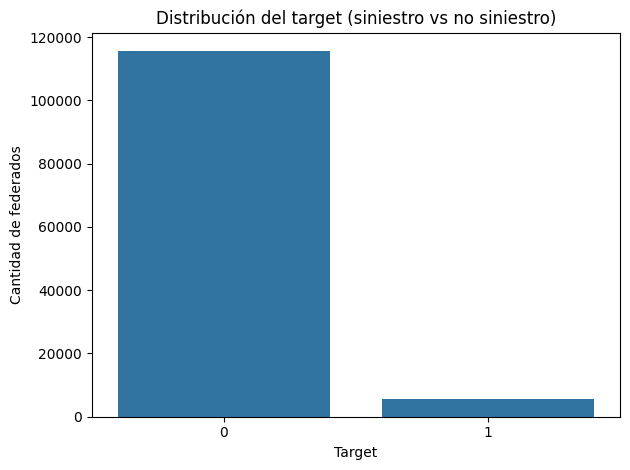

In [28]:
sns.countplot(x="target", data=df_model) 
plt.title("Distribución del target (siniestro vs no siniestro)")
plt.xlabel("Target")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

# Vemos la distribucion del target (siniestro vs no siniestro)

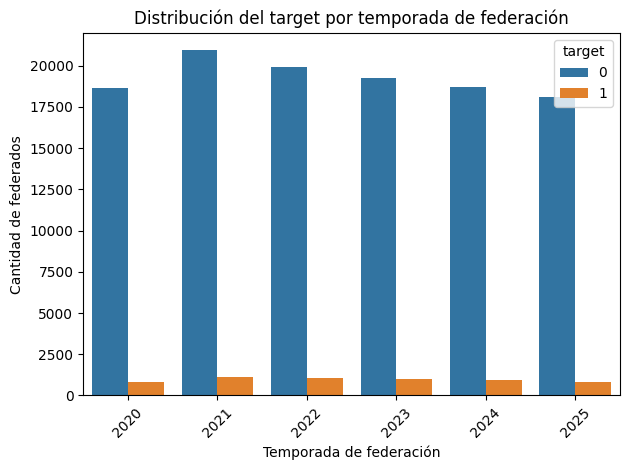

In [29]:
sns.countplot(x="temporada_federado", hue="target", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución del target por temporada de federación")
plt.xlabel("Temporada de federación")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();
 
# Vemos la distribución del target según  la temporada de federación
# Del 2020 al 2021 hay un aumento de sinietros, seguramente por la pandemia y el aumento de actividades al aire libre
# En general se mantiene una proporción bastante similar de siniestros en cada temporada

Text(0.5, 1.0, 'Proporción de siniestros')

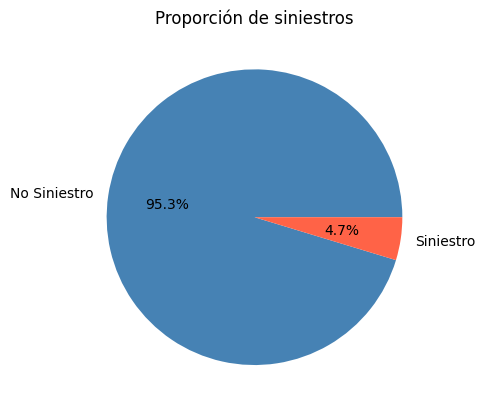

In [30]:
# Plot para la presentación:
sizes = df_model["target"].value_counts(normalize=True) * 100
plt.pie(sizes, labels=['No Siniestro', 'Siniestro'], autopct='%1.1f%%', 
        colors=['steelblue', 'tomato'])
plt.title('Proporción de siniestros')

In [31]:
df_model.groupby("temporada_federado")["target"].mean()

temporada_federado
2020    0.040940
2021    0.050408
2022    0.051594
2023    0.048146
2024    0.047081
2025    0.042158
Name: target, dtype: float64

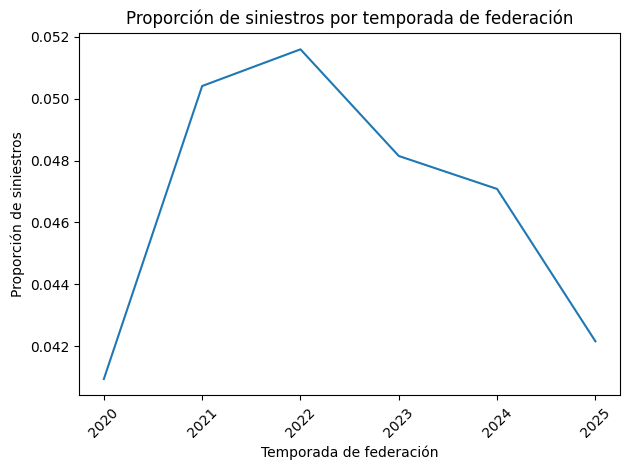

In [32]:
df_model.groupby("temporada_federado")["target"].mean().plot();
plt.xticks(rotation=45)
plt.title("Proporción de siniestros por temporada de federación")
plt.xlabel("Temporada de federación")
plt.ylabel("Proporción de siniestros")
plt.tight_layout()
plt.show();

# Agrupamos por temporada_federado y calculamos la media del target, que representa la proporción de siniestros en cada número de temporadas federado.
# Observamos un patrón creciente y luego decreciente. Esto puede deberse a varios factores,
# como diferencias en el número de observaciones por temporada o cambios en la población de federados
# Por lo que no se puede atribuir directamente a una única causa.

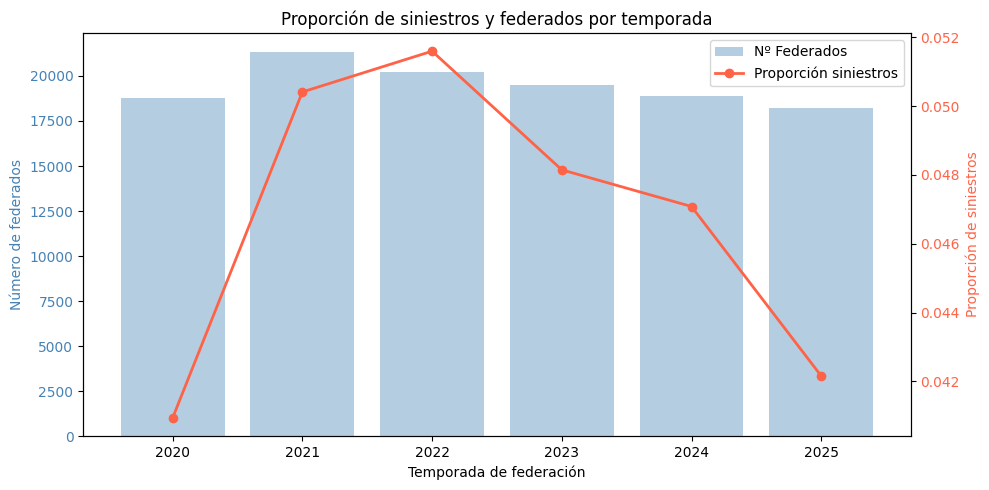

In [33]:
# Gráfica para la presentación

# Datos
proporcion = df_model.groupby("temporada_federado")["target"].mean()
federados = df_model.groupby("temporada_federado")["nsocio"].nunique()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Barras — federados (eje izquierdo)
ax1.bar(federados.index, federados.values, color='steelblue', alpha=0.4, label='Nº Federados')
ax1.set_xlabel('Temporada de federación')
ax1.set_ylabel('Número de federados', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Línea — proporción siniestros (eje derecho)
ax2 = ax1.twinx()  # twinx() significa "twin x-axis" — crea un segundo eje Y que comparte el mismo eje X.
ax2.plot(proporcion.index, proporcion.values, color='tomato', linewidth=2, marker='o', label='Proporción siniestros')
ax2.set_ylabel('Proporción de siniestros', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Proporción de siniestros y federados por temporada')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

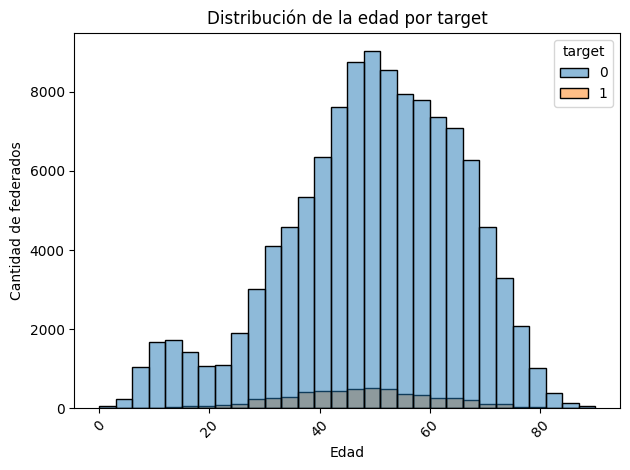

In [34]:
sns.histplot(data=df_model, x="edad", hue="target", bins=30)
plt.xticks(rotation=45)
plt.title("Distribución de la edad por target")
plt.xlabel("Edad")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

# Los siniestros parecen ser bastante proporcionales con el numero de federados por edad (más federados por edad = más siniestros por esa edad)

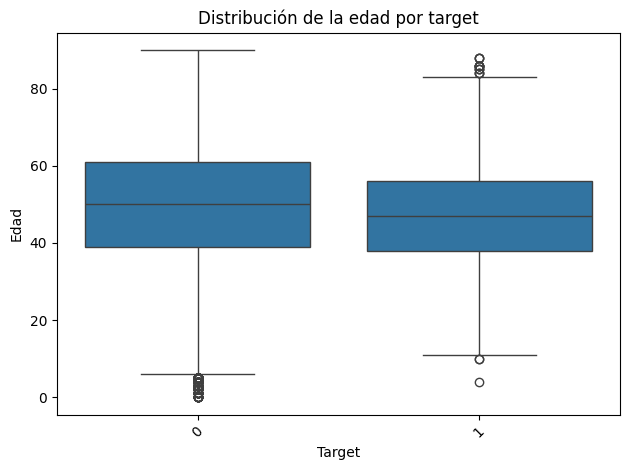

In [35]:
sns.boxplot(x="target", y="edad", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución de la edad por target")
plt.xlabel("Target")
plt.ylabel("Edad")
plt.tight_layout()
plt.show();

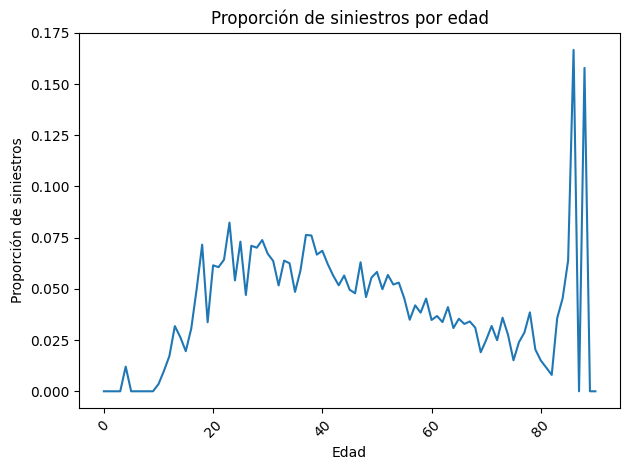

In [36]:
df_model.groupby("edad")["target"].mean().plot()
plt.xticks(rotation=45)
plt.title("Proporción de siniestros por edad")
plt.xlabel("Edad")
plt.ylabel("Proporción de siniestros")
plt.tight_layout()
plt.show();

In [37]:
# Podemos ver que el número de siniestros por edad sube con adolescentes hasta un pico en los 20s y luego se mantiene 
# A medida que sube la edad, los siniestros van bajando hasta que llegamos a los 80s, donde hay unos picos abruptos muy altos
# Los polos de edad seguramente sean proporcionales con el número de federados en esas edades
# Casi ningun niño tiene siniestros, lo cual es lógico porque no suelen hacer actividades de riesgo
# Los mayores de 80 debido a que son pocos, cualquiera que tenga un siniestro va a representar un gran porcentaje de siniestros en esa edad, lo cual explica los picos abruptos 

In [38]:
g = df.groupby("edad")["target"].agg(["mean","count"])

g.head()

,mean,count
edad,,
0,0.000000,12
1,0.000000,20
2,0.000000,23
3,0.000000,32
4,0.012048,83


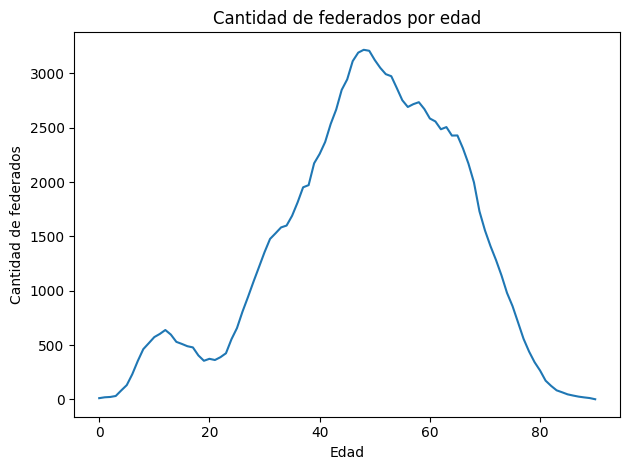

In [39]:
# Graficamos el número de registros por edad
# Esto nos permite ver si hay pocas observaciones en edades altas

g["count"].plot(title="Número de federados por edad")
plt.title("Cantidad de federados por edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

<Axes: xlabel='edad'>

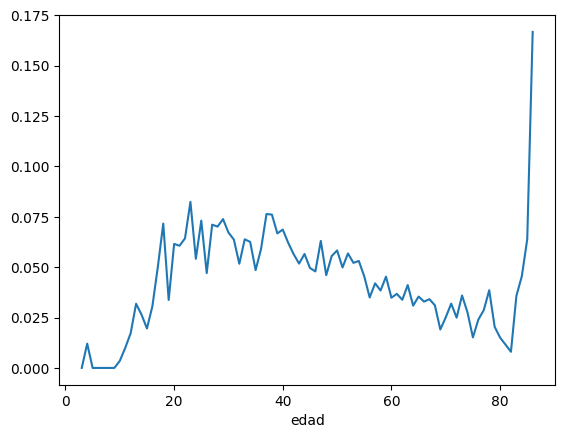

In [40]:
# Eliminamos edades con pocos registros para evitar ruido estadístico
# Con pocas observaciones, un solo siniestro puede generar picos grandes

g = df.groupby("edad")["target"].agg(["mean","count"])

g2 = g[g["count"] > 30]

g2["mean"].plot()

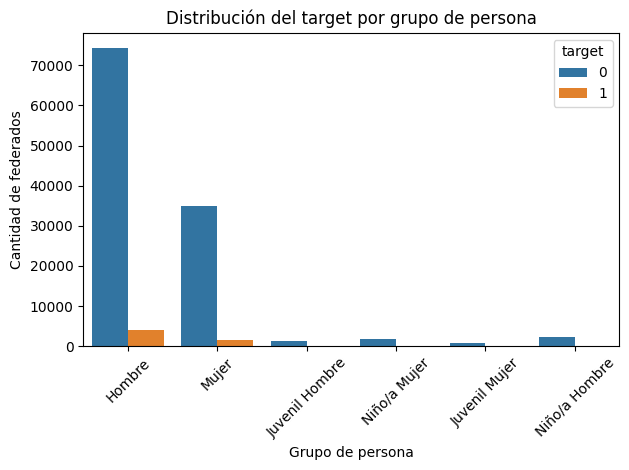

In [41]:
sns.countplot(x="grupo_persona", hue="target", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución del target por grupo de persona")
plt.xlabel("Grupo de persona")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

In [42]:
df_model.groupby("modalidad")["target"].mean().sort_values()

modalidad
B Comp.    0.000000
E Comp.    0.000000
B7         0.010811
A6         0.013333
A          0.015629
B6         0.016541
AU         0.016783
OT         0.017914
OTPromo    0.018100
B          0.049734
ROC        0.054545
C          0.077090
D          0.096527
E          0.153846
D Comp.    0.166667
Name: target, dtype: float64

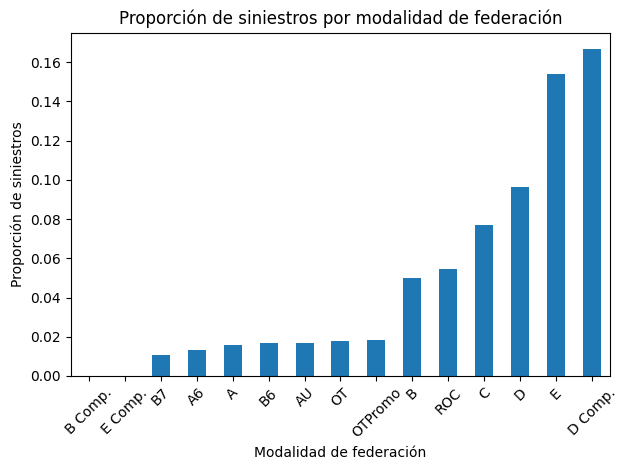

In [43]:
df_model.groupby("modalidad")["target"].mean().sort_values().plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Proporción de siniestros por modalidad de federación")
plt.xlabel("Modalidad de federación")
plt.ylabel("Proporción de siniestros")
plt.tight_layout()
plt.show();



In [44]:
# La variable modalidad representa el tipo de licencia o seguro contratado.
# Cada modalidad tiene diferentes coberturas (por ejemplo, ámbito nacional o internacional),
# lo que podría estar relacionado con la probabilidad de sufrir un siniestro.

In [45]:
df_model.modalidad.unique()

array(['B', 'A', 'AU', 'C', 'OTPromo', 'A6', 'D', 'D Comp.', 'B6', 'OT',
       'E', 'B7', 'E Comp.', 'ROC', 'B Comp.'], dtype=object)

In [46]:
# Gráfico para la presentación

df_model_modalidad = df_model.copy()

mapeo = {'A': 'Senderismo','A6':'Senderismo España' , 'OT': 'actividades otoño', 'OTPromo': 'actividades otoño',   
         'AU': 'Montaña C.A.Madrid', 'B': 'Montaña', 'B6': 'Montaña', 'B7': 'Montaña', 'B Comp.': 'Montaña competición', 'C': 'Montaña Europa y Marruecos', 
         'ROC': 'Rocodromo',
         'D': 'Montaña < 7000m mundo',                                    
         'D Comp.': 'Montaña < 7000m mundo competición',                                                       
         'E': 'Montaña > 7000m',                                    
         'E Comp.': 'Montaña > 7000m competición'                               
         }

df_model_modalidad["modalidad"] = df_model_modalidad["modalidad"].map(mapeo)

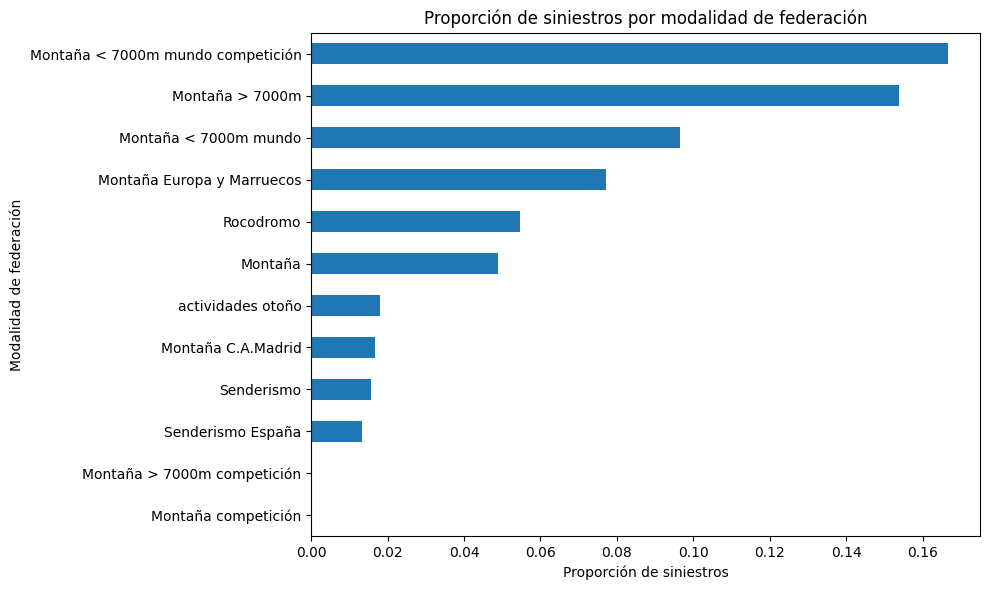

In [47]:
df_model_modalidad.groupby("modalidad")["target"].mean().sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Proporción de siniestros por modalidad de federación")
plt.xlabel("Proporción de siniestros")
plt.ylabel("Modalidad de federación")
plt.tight_layout()
plt.show()

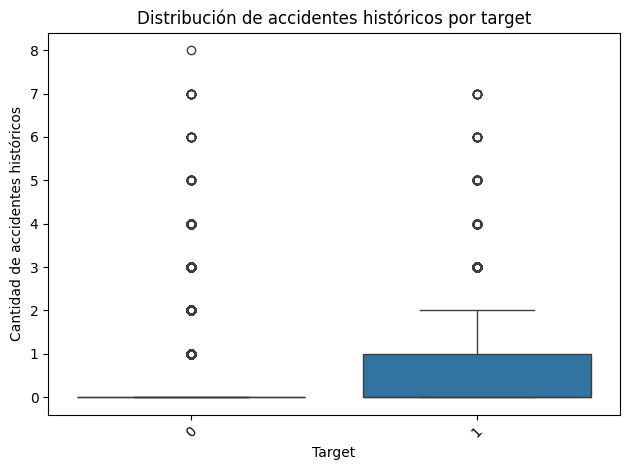

In [48]:
sns.boxplot(x="target", y="accidenteshistoricos", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución de accidentes históricos por target")
plt.xlabel("Target")
plt.ylabel("Cantidad de accidentes históricos")
plt.tight_layout()
plt.show();

In [49]:
df_model.groupby("accidenteshistoricos")["target"].mean()

accidenteshistoricos
0.0    0.034813
1.0    0.136642
2.0    0.194564
3.0    0.221763
4.0    0.311258
5.0    0.542857
6.0    0.560000
7.0    0.444444
8.0    0.000000
Name: target, dtype: float64

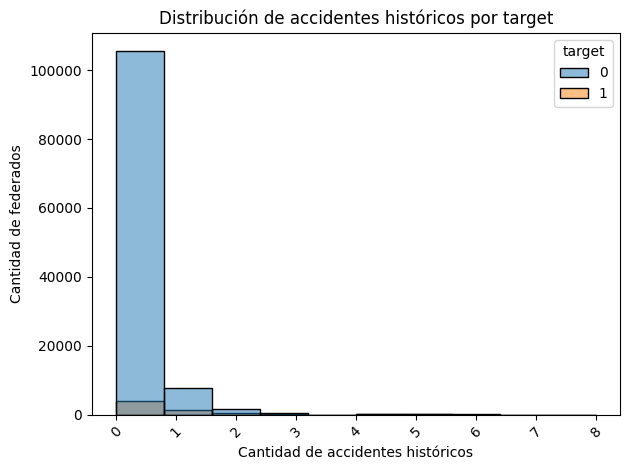

In [50]:
sns.histplot(data=df_model, x="accidenteshistoricos", hue="target", bins=10)
plt.xticks(rotation=45)
plt.title("Distribución de accidentes históricos por target")
plt.xlabel("Cantidad de accidentes históricos")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

In [51]:
# Observamos que incluso en los casos con target=1, muchos valores de accidenteshistoricos son 0. 
# Esto indica que un federado puede sufrir un siniestro aunque no tenga antecedentes previos
# Lo cual es coherente con la naturaleza del problema

In [52]:
from sklearn.model_selection import GroupShuffleSplit  
# Utilizamos GroupShuffleSplit para asegurarnos de que los datos de un mismo federado (nsocio)
# no se dividan entre entrenamiento y prueba, evitando así data leakage.

X = df_model.drop(columns=["target","nsocio"])  
# Eliminamos el target y la columna nsocio: nsocio es un identificador y no debe ser feature.

y = df_model["target"]

groups = df_model["nsocio"]  
# nsocio se usa SOLO para agrupar (group split), no para entrenar el modelo.

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))


X_train = X.iloc[train_idx].copy()  # mediante copy(), X_train deja de ser una vista de X y se convierte en un DataFrame independiente,
X_test = X.iloc[test_idx].copy()    # por lo que cualquier modificación posterior (como tu mapeo de modalidad) funcionará sin warnings
y_train = y.iloc[train_idx].copy()  # ni comportamientos inesperados.
y_test = y.iloc[test_idx].copy()

In [53]:
# Reviso nuevamente la distribución del target

y_train.value_counts(normalize=True)

target
0    0.953344
1    0.046656
Name: proportion, dtype: float64

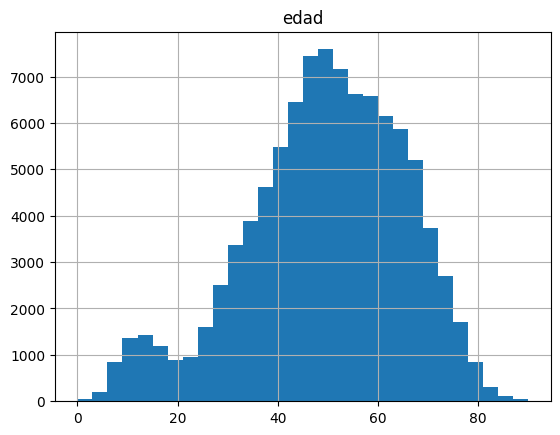

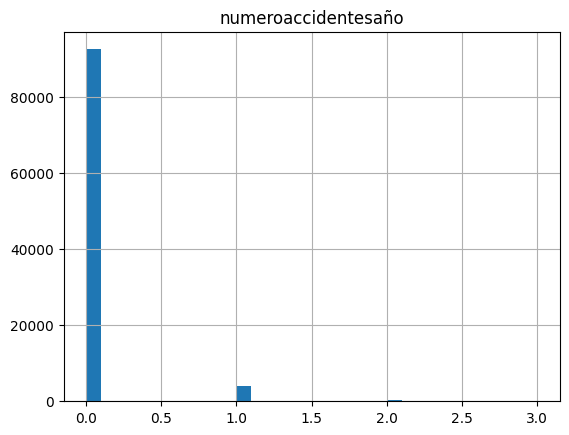

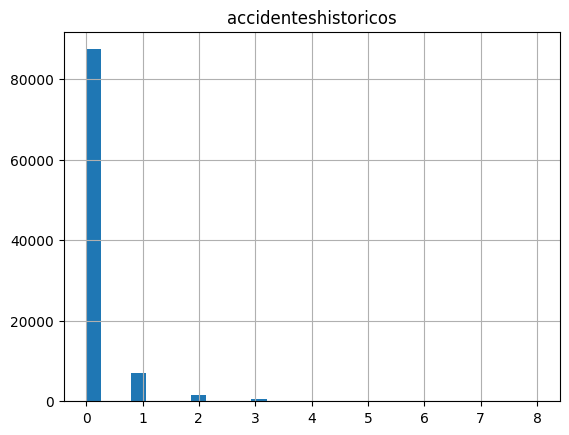

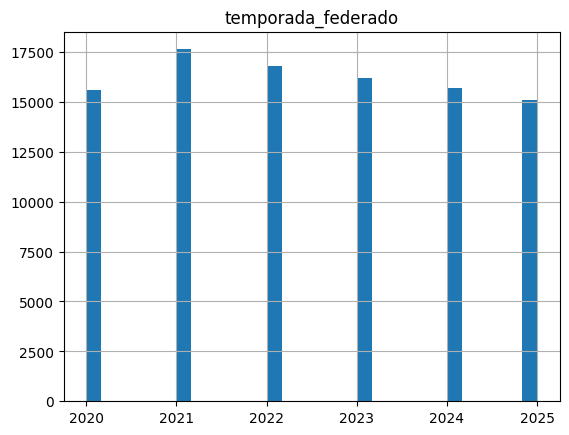

In [54]:
import matplotlib.pyplot as plt

numericas = [
    "edad",
    "numeroaccidentesaño",
    "accidenteshistoricos",
    "temporada_federado"
]

for col in numericas:
    plt.figure()
    X_train[col].hist(bins=30)
    plt.title(col)
    plt.show()
    

In [55]:
# Reviso las categoricas

for col in X_train.select_dtypes(include="object").columns:
    print(col, X_train[col].nunique())

codigopostaldomicilio 1453
numeroclub 181
modalidad 14
discapacidad 89
grupo_persona 6


In [56]:
X_train.nunique().sort_values(ascending=False)

codigopostaldomicilio    1453
numeroclub                181
edad                       91
discapacidad               89
modalidad                  14
accidenteshistoricos        9
temporada_federado          6
grupo_persona               6
numeroaccidentesaño         4
dtype: int64

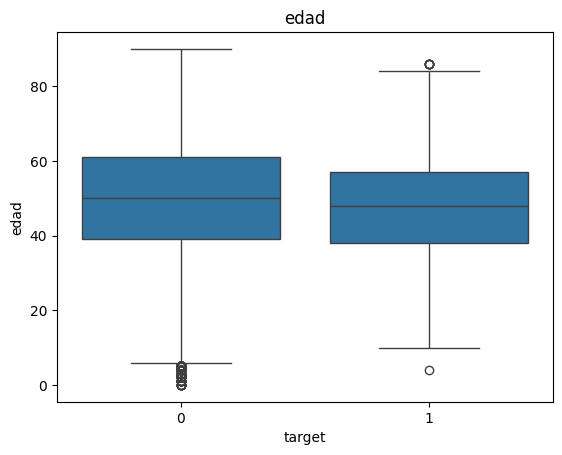

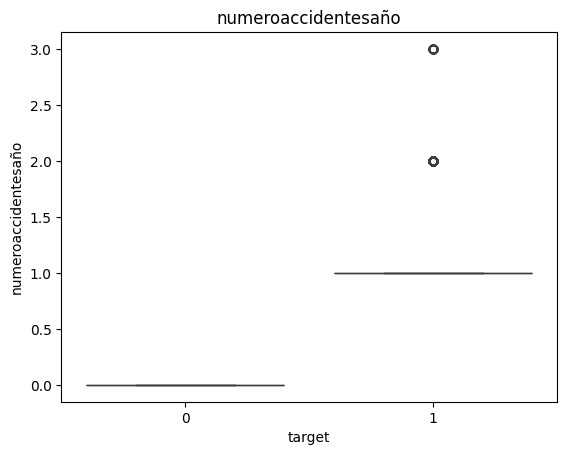

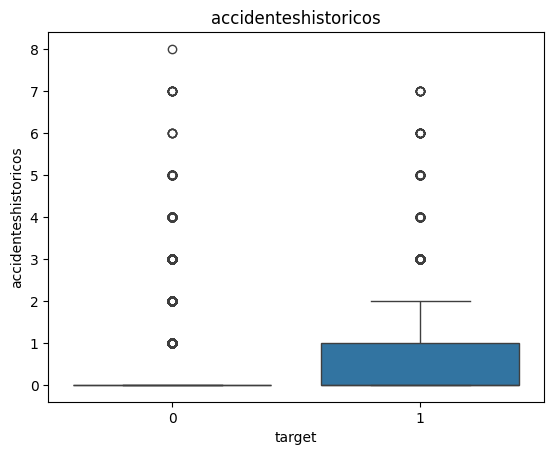

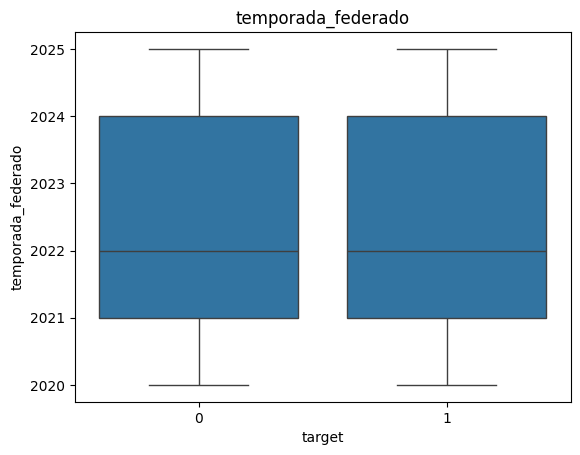

In [57]:
# Numéricas vs Target

import seaborn as sns

for col in numericas:
    plt.figure()
    sns.boxplot(x=y_train, y=X_train[col])
    plt.title(col)
    plt.show()

In [58]:
# Ahora reviso las categóricas vs Target por modalidad 

for col in ["modalidad","discapacidad","grupo_persona"]:
    print("\n", col)
    print(pd.crosstab(X_train[col], y_train, normalize="index"))


 modalidad
target            0         1
modalidad                    
A          0.983953  0.016047
A6         0.985522  0.014478
AU         0.983442  0.016558
B          0.950827  0.049173
B6         0.986198  0.013802
B7         0.987013  0.012987
C          0.923098  0.076902
D          0.889814  0.110186
D Comp.    0.833333  0.166667
E          0.833333  0.166667
E Comp.    1.000000  0.000000
OT         0.982917  0.017083
OTPromo    0.983287  0.016713
ROC        0.951220  0.048780

 discapacidad
target                                      0         1
discapacidad                                           
10% espalda                          1.000000  0.000000
15%                                  1.000000  0.000000
21% Permanente                       1.000000  0.000000
33%                                  1.000000  0.000000
33% AmputaciÃ³n transtibial derecha  1.000000  0.000000
...                                       ...       ...
85% visual                           1.000000

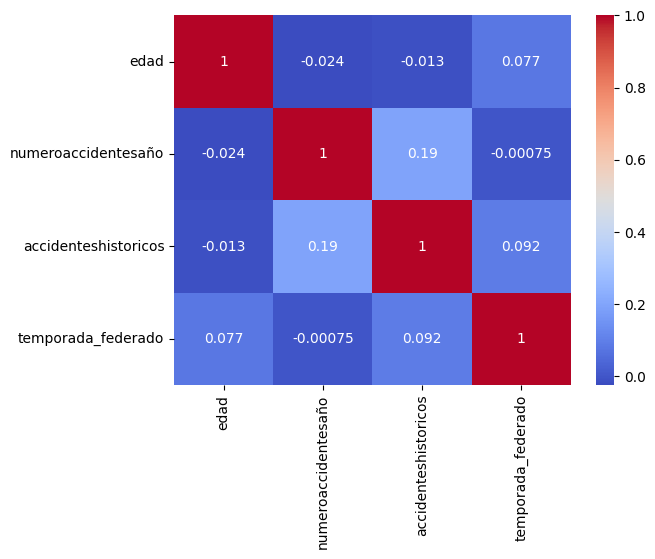

In [59]:
# Ahora la correlación entre las numéricas

corr = X_train[numericas].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [60]:
# Varianza 
for col in X_train.columns:
    if X_train[col].nunique() <= 1:
        print(col)

In [61]:
# Revisamos nuevamente las columas para entender cuales tienen que tener un encoding

df_model.head(5)

,nsocio,codigopostaldomicilio,numeroclub,modalidad,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,59794,28232,07.28.000,B,NO,0.0,0,0.0,89,2020,Hombre
1,59794,28232,07.28.000,B,NO,0.0,0,0.0,90,2021,Hombre
2,3,28043,07.28.012,B,NO,0.0,0,0.0,88,2020,Hombre
3,12,28028,07.28.060,A,NO,0.0,0,0.0,80,2020,Mujer
4,12,28028,07.28.060,A,NO,0.0,0,0.0,81,2021,Mujer


<Axes: xlabel='target', ylabel='Count'>

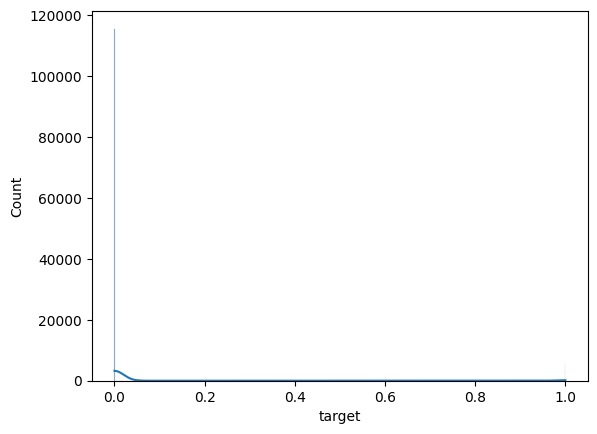

In [62]:
# Las columnas modalidad, discapacidad,y grupo persona deben transformarse

#Reviso distribución de target

sns.histplot(df_model["target"], kde= True)

In [63]:
X_train.head(10)

,codigopostaldomicilio,numeroclub,modalidad,discapacidad,numeroaccidentesaño,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,28232,07.28.000,B,NO,0.0,0.0,89,2020,Hombre
1,28232,07.28.000,B,NO,0.0,0.0,90,2021,Hombre
2,28043,07.28.012,B,NO,0.0,0.0,88,2020,Hombre
3,28028,07.28.060,A,NO,0.0,0.0,80,2020,Mujer
4,28028,07.28.060,A,NO,0.0,0.0,81,2021,Mujer
5,28028,07.28.060,A,NO,0.0,0.0,82,2022,Mujer
6,28028,07.28.060,A,NO,0.0,0.0,83,2023,Mujer
7,28028,07.28.060,A,NO,0.0,0.0,84,2024,Mujer
8,28028,07.28.060,A,NO,0.0,0.0,85,2025,Mujer
9,45940,07.28.325,AU,NO,0.0,0.0,80,2020,Hombre


In [64]:
numericas = [
    "edad",
    "numeroaccidentesaño",
    "accidenteshistoricos",
    "temporada_federado"
]

categoricas = [
    "modalidad",
    "discapacidad",
    "grupo_persona",
    "numeroclub",
    "codigopostaldomicilio"
]

In [65]:
# Hacemos un t-test para ver las variables estadísticas

from scipy.stats import ttest_ind

for col in numericas:
    grupo0 = X_train[col][y_train == 0]
    grupo1 = X_train[col][y_train == 1]
    
    stat, p = ttest_ind(grupo0, grupo1, equal_var=False)
    
    print(f"{col} → p-value: {p}")

edad → p-value: 1.0157583365184966e-16
numeroaccidentesaño → p-value: 0.0
accidenteshistoricos → p-value: 1.8453405054524054e-175
temporada_federado → p-value: 0.9468031605171578


In [66]:
# se podría eliminar temporada federado

In [67]:
#hacemos un mutual info

from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X_train[numericas],
    y_train,
    discrete_features=False
)

for col, score in zip(numericas, mi):
    print(col, score)

edad 0.0033946775791569017
numeroaccidentesaño 0.18879717858690814
accidenteshistoricos 0.012279721144500488
temporada_federado 0.004069644331410771


In [68]:
# numeroaccidentesaño es la que mayor podder predictivo guarda
# temporada_federado candidata a eliminarse
X_train[["numeroaccidentesaño","accidenteshistoricos"]].corr()

,numeroaccidentesaño,accidenteshistoricos
numeroaccidentesaño,1.000000,0.193796
accidenteshistoricos,0.193796,1.000000


In [69]:
#vemos las categóricas con un chi cuadrado

from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import chi2

encoder = OrdinalEncoder()
X_cat_encoded = encoder.fit_transform(X_train[categoricas])

chi_scores, p_values = chi2(X_cat_encoded, y_train)

for col, p in zip(categoricas, p_values):
    print(f"{col} → p-value: {p}")

modalidad → p-value: 5.945357350692408e-53
discapacidad → p-value: 0.8541163075904896
grupo_persona → p-value: 3.7380915694207263e-25
numeroclub → p-value: 0.0
codigopostaldomicilio → p-value: 0.0


In [70]:
# eliminaria discapacidad  Mantendría las siguientes: 

 #Numéricas

#edad

#numeroaccidentesaño (t-1)

#accidenteshistoricos

# Categóricas
#modalidad

#grupo_persona

# Eliminaría temporada_federado - discapacidad - numeroclub (por ahora) - codigopostaldomicilio (por ahora)

Antes de avanzar eligiría las features finales asi:
features_numericas = [
    "edad",
    "numeroaccidentesaño",
    "accidenteshistoricos"
]

features_categoricas = [
    "modalidad",
    "grupo_persona"
]

In [71]:
X_train

,codigopostaldomicilio,numeroclub,modalidad,discapacidad,numeroaccidentesaño,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,28232,07.28.000,B,NO,0.0,0.0,89,2020,Hombre
1,28232,07.28.000,B,NO,0.0,0.0,90,2021,Hombre
2,28043,07.28.012,B,NO,0.0,0.0,88,2020,Hombre
3,28028,07.28.060,A,NO,0.0,0.0,80,2020,Mujer
4,28028,07.28.060,A,NO,0.0,0.0,81,2021,Mujer
...,...,...,...,...,...,...,...,...,...
121271,28080,07.28.475,AU,NO,0.0,0.0,28,2025,Mujer
121272,28045,07.28.370,B,NO,0.0,0.0,34,2025,Mujer
121273,28016,07.28.000,C,NO,0.0,0.0,22,2025,Mujer
121274,46007,07.28.000,OT,NO,0.0,0.0,29,2025,Hombre


In [72]:
X_train["modalidad"].unique()

array(['B', 'A', 'AU', 'C', 'OTPromo', 'A6', 'D', 'D Comp.', 'B6', 'OT',
       'E', 'B7', 'E Comp.', 'ROC'], dtype=object)

In [73]:
# Codificar modalidad mediante mapeo, hay una relación entre modalidad de seguro y riesgo.
# de 1 a 7 de menor a mayor riesgo. 
mapeo = {'A': 1,'A6': 1, 'OT': 1, 'OTPromo':1,    # Senderismo y actividades de otoño.
         'AU': 2, 'B': 2, 'B6': 2, 'B7': 2, 'C': 2, # Montaña sin llegar a cotas muy altas en diferentes ambitos geográficos
         'ROC': 3,                                  # Rocodromo
         'D': 4,                                    # Montaña a nivel mundial en cotas más altas que las anteriores
         'D Comp.': 5,                              # Igual que D pero en competición.                          
         'E': 6,                                    # Montañas por encima de los 7000 metros
         'E Comp.': 7                               # Igual que E pero en competición.
         }

X_train["modalidad"] = X_train["modalidad"].map(mapeo)


In [74]:
# Lo mismo en test
X_test["modalidad"] = X_test["modalidad"].map(mapeo)

In [75]:
# Compruebo que no hay nulos (me ha saltado un error en el modelo)
X_test.modalidad.unique()

array([ 2.,  1.,  4.,  5.,  7., nan,  3.,  6.])

In [76]:
# La moda train para rellenar los nulos de test
moda_modalidad = X_train["modalidad"].mode()[0]
X_test["modalidad"] = X_test["modalidad"].fillna(moda_modalidad)

In [77]:
# Compruebo si quedan nulos
X_test.isna().sum()

codigopostaldomicilio    0
numeroclub               0
modalidad                0
discapacidad             0
numeroaccidentesaño      0
accidenteshistoricos     0
edad                     0
temporada_federado       0
grupo_persona            0
dtype: int64

In [78]:
# Teniendo en cuenta la distribución del target con grupo_persona vamos a codificar con ONEHOTENCODING,
#  ya que parece que no hay una relación de grado.
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoded = encoder.fit_transform(X_train[["grupo_persona"]])
# Crear DataFrame con los nombres de las nuevas columnas
encoded_df = pd.DataFrame(encoded, 
                          columns=encoder.get_feature_names_out(["grupo_persona"]),
                          index=X_train.index)  # importante mantener el índice

# Añadir al DataFrame las nuevas columnas y eliminar "grupo_persona"
X_train = pd.concat([X_train, encoded_df], axis=1)
X_train = X_train.drop(columns=["grupo_persona"])



In [79]:
# Lo mismo en test
encoded_test = encoder.transform(X_test[["grupo_persona"]])
encoded_test_df = pd.DataFrame(encoded_test,
                                columns=encoder.get_feature_names_out(["grupo_persona"]),
                                index=X_test.index)

X_test = pd.concat([X_test, encoded_test_df], axis=1)
X_test = X_test.drop(columns=["grupo_persona"])

In [80]:
# Comprobar si están todas las categorías en el encoder
print(encoder.categories_)

[array(['Hombre', 'Juvenil Hombre', 'Juvenil Mujer', 'Mujer',
       'Niño/a Hombre', 'Niño/a Mujer'], dtype=object)]


In [81]:
# Comprobamos las columnas
X_train.columns

Index(['codigopostaldomicilio', 'numeroclub', 'modalidad', 'discapacidad',
       'numeroaccidentesaño', 'accidenteshistoricos', 'edad',
       'temporada_federado', 'grupo_persona_Juvenil Hombre',
       'grupo_persona_Juvenil Mujer', 'grupo_persona_Mujer',
       'grupo_persona_Niño/a Hombre', 'grupo_persona_Niño/a Mujer'],
      dtype='object')

In [82]:
#Crear los df para los modelos con las columnas seleccionadas.
X_train_modelo = X_train[["edad", "numeroaccidentesaño", "accidenteshistoricos", "modalidad", 'grupo_persona_Juvenil Hombre',
       'grupo_persona_Juvenil Mujer', 'grupo_persona_Mujer',
       'grupo_persona_Niño/a Hombre', 'grupo_persona_Niño/a Mujer']].copy()
X_test_modelo = X_test[["edad", "numeroaccidentesaño", "accidenteshistoricos", "modalidad", 'grupo_persona_Juvenil Hombre',
       'grupo_persona_Juvenil Mujer', 'grupo_persona_Mujer',
       'grupo_persona_Niño/a Hombre', 'grupo_persona_Niño/a Mujer']].copy()

In [83]:
#Verificamos que todo está correcto:
# Dimensiones
print(X_train_modelo.shape)
print(X_test_modelo.shape)
# Que no haya nulos
print(X_train_modelo.isna().sum())
# Tipos de datos (todo debería ser numérico)
print(X_train_modelo.dtypes)

(96943, 9)
(24333, 9)
edad                            0
numeroaccidentesaño             0
accidenteshistoricos            0
modalidad                       0
grupo_persona_Juvenil Hombre    0
grupo_persona_Juvenil Mujer     0
grupo_persona_Mujer             0
grupo_persona_Niño/a Hombre     0
grupo_persona_Niño/a Mujer      0
dtype: int64
edad                              int64
numeroaccidentesaño             float64
accidenteshistoricos            float64
modalidad                         int64
grupo_persona_Juvenil Hombre    float64
grupo_persona_Juvenil Mujer     float64
grupo_persona_Mujer             float64
grupo_persona_Niño/a Hombre     float64
grupo_persona_Niño/a Mujer      float64
dtype: object


In [84]:
# Comprobar si hay que escalar
X_train_modelo.describe()

,edad,numeroaccidentesaño,accidenteshistoricos,modalidad,grupo_persona_Juvenil Hombre,grupo_persona_Juvenil Mujer,grupo_persona_Mujer,grupo_persona_Niño/a Hombre,grupo_persona_Niño/a Mujer
count,96943.000000,96943.000000,96943.000000,96943.000000,96943.000000,96943.000000,96943.000000,96943.000000,96943.000000
mean,48.880167,0.052247,0.136193,1.917735,0.010645,0.006086,0.302982,0.019795,0.015679
std,15.914633,0.248334,0.482309,0.426318,0.102627,0.077776,0.459550,0.139296,0.124232
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,61.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,90.000000,3.000000,8.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000


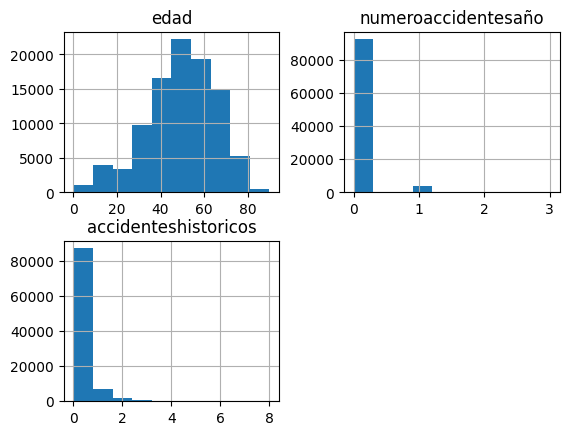

In [85]:
X_train_modelo[["edad", "numeroaccidentesaño","accidenteshistoricos"]].hist();

In [86]:
X_train_modelo["numeroaccidentesaño"].unique()

array([0., 1., 2., 3.])

In [87]:
# Normalizar debido a su distribución de larga cola
X_train_modelo["accidenteshistoricos"] = np.log1p(X_train_modelo["accidenteshistoricos"])

X_test_modelo["accidenteshistoricos"] = np.log1p(X_test_modelo["accidenteshistoricos"])

In [88]:
# Escalamos las númericas necesarias:
from sklearn.preprocessing import RobustScaler   
# RobustScaler que es robusto a outliers porque usa la mediana y el IQR en vez de la media y desviación típica.

cols_escalar = ["edad", "numeroaccidentesaño", "accidenteshistoricos", "modalidad"]
# Las columnas OneHotEncoded no hay que escalar, valores 0 / 1
scaler = RobustScaler()
X_train_modelo[cols_escalar] = scaler.fit_transform(X_train_modelo[cols_escalar])
X_test_modelo[cols_escalar] = scaler.transform(X_test_modelo[cols_escalar])

# Baseline

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23169
           1       1.00      1.00      1.00      1164

    accuracy                           1.00     24333
   macro avg       1.00      1.00      1.00     24333
weighted avg       1.00      1.00      1.00     24333

AUC-ROC: 1.0000


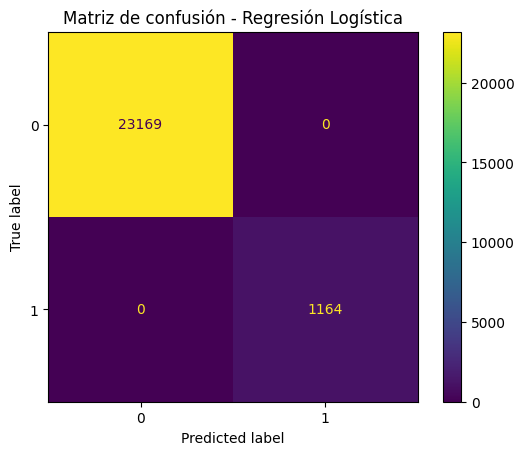

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# Entrenar
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_modelo, y_train)

# Predecir
y_pred = lr.predict(X_test_modelo)
y_prob = lr.predict_proba(X_test_modelo)[:, 1] 

# Métricas
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

Esto es demasiado perfecto — un modelo real nunca da 1.00 en todo. Hay data leakage casi con total seguridad.  
Las causas más probables:  
1. Alguna feature está filtrando el target — hay una columna que de alguna forma contiene información del siniestro.  
2. accidenteshistoricos o numeroaccidentesaño — ¿estos datos incluyen el siniestro que estamos intentando predecir? Si es así, son datos del futuro usados como feature.  
3. nsocio colado en el modelo — comprobar que no está entre las features.  

La pregunta clave es: ¿accidenteshistoricos y numeroaccidentesaño se calcularon incluyendo el año del siniestro que se quiere predecir? Ese sería el error más común en este tipo de proyectos.

In [94]:
print(X_train_modelo.columns.tolist())
# Revisa la correlación de cada variable con el target
# Si hay correlación perfecta o casi perfecta, ahí está el leakage
print(df_model[["numeroaccidentesaño", "accidenteshistoricos", "target"]].corr())

['edad', 'numeroaccidentesaño', 'accidenteshistoricos', 'modalidad', 'grupo_persona_Juvenil Hombre', 'grupo_persona_Juvenil Mujer', 'grupo_persona_Mujer', 'grupo_persona_Niño/a Hombre', 'grupo_persona_Niño/a Mujer']
                      numeroaccidentesaño  accidenteshistoricos   target
numeroaccidentesaño              1.000000              0.185628  0.95010
accidenteshistoricos             0.185628              1.000000  0.18426
target                           0.950100              0.184260  1.00000


Confirmado. 'numeroaccidentesaño' tiene correlación 0.95 con el target — es leakage claro. El modelo básicamente está mirando la respuesta.
Esa columna está contando los accidentes del mismo año que estás prediciendo, con lo que es información del futuro usada como feature.

In [95]:
# Quito la feature que causa leakage
X_train_modelo = X_train_modelo.drop("numeroaccidentesaño", axis=1)
X_test_modelo = X_test_modelo.drop("numeroaccidentesaño", axis=1)

              precision    recall  f1-score   support

           0       0.97      0.80      0.88     23169
           1       0.10      0.43      0.16      1164

    accuracy                           0.79     24333
   macro avg       0.53      0.61      0.52     24333
weighted avg       0.92      0.79      0.84     24333

AUC-ROC: 0.6808


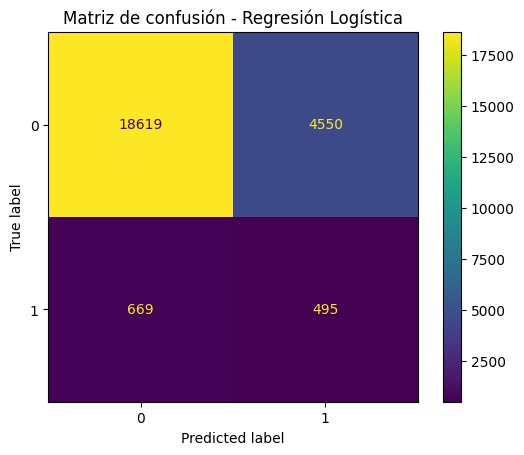

In [96]:
# Volvemos a entrenar
lr.fit(X_train_modelo, y_train)

# Predecir
y_pred = lr.predict(X_test_modelo)
y_prob = lr.predict_proba(X_test_modelo)[:, 1] 

# Métricas
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

El mensaje para la presentación:

"Con un modelo baseline simple y solo 7 variables disponibles, obtenemos un AUC de 0.68. Esto confirma que hay señal predictiva en los datos y justifica explorar modelos más complejos."